# Lab 08: Scaling, PCA, Clustering and Regression

This notebook works through a complete **unsupervised-to-supervised** machine learning workflow on a single real dataset.
The focus is on understanding how feature scaling, dimensionality reduction, clustering, and regression fit together, and on interpreting what each step tells you.

Predictive performance is NOT the goal of this lab. Understanding the workflow and reading the results honestly is.

We use the **auto-mpg** dataset: 398 cars from the 1970s–80s, each described by engine and physical specifications, its fuel economy (`mpg`), and its country of `origin`. The same data wears two hats:
- **Unsupervised** (Steps 2–5): we cluster cars on their physical specs, with `origin` held back as a hidden label to check against.
- **Supervised** (Step 6): we predict `mpg` from those same specs.

---

## Learning Outcomes

By the end of this lab, you should be able to:
1. Explain why distance-based methods require feature scaling, and apply `StandardScaler` correctly.
2. Use PCA to reduce dimensionality, and interpret explained variance and component loadings.
3. Apply k-means and choose the number of clusters using the elbow method.
4. Apply DBSCAN, and explain how it differs from k-means in handling cluster shape and outliers.
5. Train and evaluate a linear regression model, distinguish MAE, RMSE and R², and avoid data leakage when scaling.

## 0. Environment Setup

We import everything up front. `RANDOM_STATE` is fixed so every result in this notebook is reproducible.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             r2_score, adjusted_rand_score)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams["figure.figsize"] = (6, 4)
print("Setup complete.")

Setup complete.


## Step 1: Load and inspect the data

In scikit-learn, data is represented as **features (X)** and, for supervised problems, a **target (y)**. We start by loading the raw table.

### Step 1.1: Load the dataset

In [ ]:
URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
raw = pd.read_csv(URL)
print("Raw shape:", raw.shape)
raw.head()

Raw shape: (398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


### Step 1.2: Handle missing values

Real data is rarely tidy. Before modelling, always check for missing values — methods like PCA and k-means cannot accept them.

**Common mistake to highlight!**

Students often feed a dataframe straight into a model without checking, then get a confusing error deep inside scikit-learn. Check first.

In [ ]:
print("Missing values per column:")
print(raw.isna().sum()[raw.isna().sum() > 0])

Missing values per column:
horsepower    6
dtype: int64


`horsepower` has a handful of missing values. The simplest fix here is to drop those rows so every method gets complete cases. We then choose our five physical features, and keep `mpg` and `origin` alongside.

In [ ]:
features = ["cylinders", "displacement", "horsepower", "weight", "acceleration"]

df = raw.dropna(subset=["horsepower"]).reset_index(drop=True)
print(f"Rows after dropping missing horsepower: {len(df)}")

X = df[features].values          # the five physical specs
origin = df["origin"].values     # USA / Europe / Japan, for checking only
y_origin = pd.factorize(origin)[0]

df[features + ["mpg", "origin"]].describe().round(1)

Rows after dropping missing horsepower: 392


,cylinders,displacement,horsepower,weight,acceleration,mpg
count,392.0,392.0,392.0,392.0,392.0,392.0
mean,5.5,194.4,104.5,2977.6,15.5,23.4
std,1.7,104.6,38.5,849.4,2.8,7.8
min,3.0,68.0,46.0,1613.0,8.0,9.0
25%,4.0,105.0,75.0,2225.2,13.8,17.0
50%,4.0,151.0,93.5,2803.5,15.5,22.8
75%,8.0,275.8,126.0,3614.8,17.0,29.0
max,8.0,455.0,230.0,5140.0,24.8,46.6


**Rule of thumb**

Clustering is unsupervised: the algorithm must not see the labels. We hold `origin` aside and only use it *afterwards* to check what the clusters captured.

## Step 2: Feature scaling with StandardScaler

### Step 2.1: Why scaling is needed

Look at the ranges in the table above: `weight` runs into the thousands, `acceleration` sits around 15, `cylinders` is 3–8. Any method that measures **distance** — k-means, DBSCAN, PCA — would let `weight` dominate completely, purely because its numbers are larger. Scaling is not optional here.

`StandardScaler` transforms each feature to **mean 0, standard deviation 1**:

$$ z = \frac{x - \mu}{\sigma} $$

**Rule of thumb**

Before any distance- or variance-based method, scale your features so each contributes on equal terms.

### Step 2.2: Apply the scaler

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

before = pd.DataFrame(X, columns=features).agg(["mean", "std"]).round(1)
after  = pd.DataFrame(X_scaled, columns=features).agg(["mean", "std"]).round(1)
print("BEFORE scaling:")
print(before)
print("\nAFTER scaling:")
print(after)

BEFORE scaling:
      cylinders  displacement  horsepower  weight  acceleration
mean        5.5         194.4       104.5  2977.6          15.5
std         1.7         104.6        38.5   849.4           2.8

AFTER scaling:
      cylinders  displacement  horsepower  weight  acceleration
mean       -0.0          -0.0        -0.0    -0.0           0.0
std         1.0           1.0         1.0     1.0           1.0


Means are now ~0 and standard deviations ~1. We scale **once** here and reuse `X_scaled` for PCA and both clustering methods.

(Note: scaling the whole dataset is fine for *unsupervised* exploration. For the *supervised* regression in Step 6 we will be stricter and fit the scaler on training data only — that distinction matters, and we return to it.)

## Step 3: Dimensionality reduction with PCA

The five specs are strongly correlated: big-engined cars tend to be heavy, high-powered, and have more cylinders. **Principal Component Analysis** rotates the data onto new axes ordered by how much variance they capture, so we can plot every car in 2D with little loss.

### Step 3.1: Fit PCA and check explained variance

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

evr = pca.explained_variance_ratio_
print(f"Variance captured by PC1: {evr[0]:.1%}")
print(f"Variance captured by PC2: {evr[1]:.1%}")
print(f"Total in 2 components:    {evr.sum():.1%}")

Variance captured by PC1: 81.4%
Variance captured by PC2: 13.9%
Total in 2 components:    95.3%


### Step 3.2: Interpret the component loadings

A principal component is a weighted combination of the original features. The **loadings** tell us what each component means.

In [ ]:
loadings = pd.DataFrame(pca.components_.T, index=features, columns=["PC1", "PC2"])
loadings.round(2)

,PC1,PC2
cylinders,0.47,0.22
displacement,0.48,0.18
horsepower,0.47,-0.12
weight,0.46,0.35
acceleration,-0.33,0.89


All five specs load on PC1 with the same sign — so PC1 is essentially a single **"size and power"** axis: large values mean bigger, heavier, more powerful cars.

**Rule of thumb**

PCA is for compression and visualisation. Always interpret the loadings — a component is only useful if you can say what it represents.

### Step 3.3: Visualise the cars in 2D

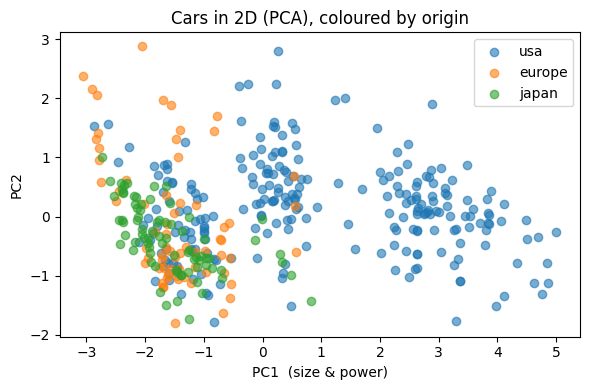

In [ ]:
plt.figure()
for name in ["usa", "europe", "japan"]:
    mask = origin == name
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=name, alpha=0.6)
plt.xlabel("PC1  (size & power)"); plt.ylabel("PC2")
plt.title("Cars in 2D (PCA), coloured by origin")
plt.legend(); plt.tight_layout(); plt.show()

American cars spread toward the large-and-powerful end; Japanese and European cars cluster at the small-and-efficient end. We reuse these PCA coordinates only to **visualise** the clustering below.

## Step 4: K-means clustering

K-means partitions points into *k* groups by minimising the distance from each point to its cluster centre. You must choose *k* in advance.

### Step 4.1: Choose k with the elbow method

Plot the within-cluster sum of squares (inertia) against *k*, and look for the bend where adding clusters stops helping much.

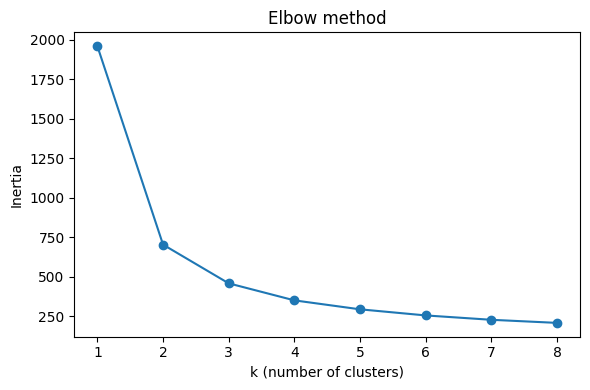

In [ ]:
inertias = []
ks = range(1, 9)
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure()
plt.plot(list(ks), inertias, "o-")
plt.xlabel("k (number of clusters)"); plt.ylabel("Inertia")
plt.title("Elbow method"); plt.tight_layout(); plt.show()

### Step 4.2: Fit k-means and check against origin

The bend sits around **k = 3**. We fit with that value and plot on the PCA axes.

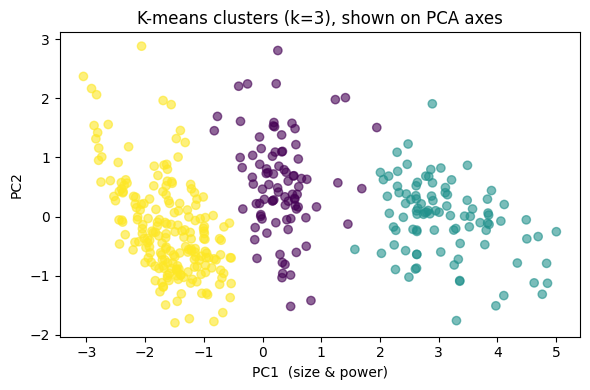

In [ ]:
km = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
km_labels = km.fit_predict(X_scaled)

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=km_labels, cmap="viridis", alpha=0.6)
plt.xlabel("PC1  (size & power)"); plt.ylabel("PC2")
plt.title("K-means clusters (k=3), shown on PCA axes")
plt.tight_layout(); plt.show()

## Step 5: DBSCAN clustering

K-means assumes clusters are roughly round and forces *every* point into one. **DBSCAN** instead groups points that are densely packed, and labels sparse points as **noise** (cluster `-1`). It needs no *k*, but two parameters:
- `eps` — how close counts as "neighbouring"
- `min_samples` — how many neighbours make a dense region

### Step 5.1: Fit DBSCAN

DBSCAN found 5 cluster(s) and flagged 39 cars as noise.


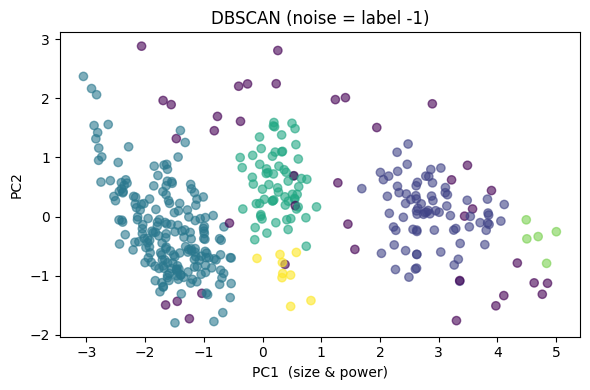

In [ ]:
db = DBSCAN(eps=0.6, min_samples=5)
db_labels = db.fit_predict(X_scaled)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = int((db_labels == -1).sum())
print(f"DBSCAN found {n_clusters} cluster(s) and flagged {n_noise} cars as noise.")

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=db_labels, cmap="viridis", alpha=0.6)
plt.xlabel("PC1  (size & power)"); plt.ylabel("PC2")
plt.title("DBSCAN (noise = label -1)")
plt.tight_layout(); plt.show()

### Step 5.2: Inspect the outliers

Because DBSCAN flags sparse points as noise, we can read off the unusual cars directly — something k-means cannot do.

In [ ]:
outliers = df.loc[db_labels == -1, ["name", "mpg"] + features]
print("A few cars flagged as noise:")
outliers.head(8)

A few cars flagged as noise:


,name,mpg,cylinders,displacement,horsepower,weight,acceleration
5,ford galaxie 500,15.0,8,429.0,198.0,4341,10.0
6,chevrolet impala,14.0,8,454.0,220.0,4354,9.0
7,plymouth fury iii,14.0,8,440.0,215.0,4312,8.5
9,amc ambassador dpl,15.0,8,390.0,190.0,3850,8.5
11,plymouth 'cuda 340,14.0,8,340.0,160.0,3609,8.0
12,chevrolet monte carlo,15.0,8,400.0,150.0,3761,9.5
13,buick estate wagon (sw),14.0,8,455.0,225.0,3086,10.0
25,ford f250,10.0,8,360.0,215.0,4615,14.0


### Step 5.3: The effect of `eps`

`eps` controls everything. Too small and most points become noise; too large and everything merges into one blob.

In [ ]:
for eps in [0.4, 0.6, 0.8, 1.0]:
    lbl = DBSCAN(eps=eps, min_samples=5).fit_predict(X_scaled)
    n_c = len(set(lbl)) - (1 if -1 in lbl else 0)
    print(f"eps={eps}:  clusters={n_c}  noise={(lbl==-1).sum()}")

eps=0.4:  clusters=6  noise=111
eps=0.6:  clusters=5  noise=39
eps=0.8:  clusters=2  noise=16
eps=1.0:  clusters=2  noise=6


**Common mistake to highlight!**

Students expect DBSCAN to "just work" out of the box like k-means. It will not — its output depends entirely on `eps` and `min_samples`. Choosing them well is the real work, and it is a *density* judgement, not a count.

**Rule of thumb**

DBSCAN's strength is less about tidy groups and more about flagging the oddballs automatically.

## Step 6: Linear regression: predicting mpg

Clustering is unsupervised. Now a **supervised** task on the same cars: predict fuel economy from the five physical specs.

### Step 6.1: Define predictors and target

In [ ]:
Xr = X                      # the five physical specs
y_mpg = df["mpg"].values    # continuous target, in mpg
print("Predictors:", features)
print("Target    : mpg")

Predictors: ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']
Target    : mpg


### Step 6.2: Split first, then scale on the training data only

This is the discipline that keeps evaluation honest.

**Common mistake to highlight!**

A very common bug is to scale the *whole* dataset and then split:
```python
X_scaled_all = StandardScaler().fit_transform(Xr)   # WRONG: sees the test set
X_train, X_test = train_test_split(X_scaled_all, ...)
```
This lets information from the test set (its mean and standard deviation) leak into training. The correct order is **split, then fit the scaler on the training set only**, and apply it to both.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    Xr, y_mpg, test_size=0.2, random_state=RANDOM_STATE)

reg_scaler = StandardScaler().fit(X_train)   # fit on TRAIN only
X_train_s = reg_scaler.transform(X_train)
X_test_s  = reg_scaler.transform(X_test)     # reuse the same scaler

print("Train:", X_train_s.shape, "| Test:", X_test_s.shape)

Train: (313, 5) | Test: (79, 5)


### Step 6.3: Fit and predict

In [ ]:
model = LinearRegression().fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)
print("Model trained.")

Model trained.


### Step 6.4: Evaluate with MAE, RMSE and R²

- **MAE** — average size of the miss, in the target's units (mpg). Robust to outliers.
- **RMSE** — same units, but squares errors first, so large misses are punished harder.
- **R²** — share of variance explained; 1.0 is perfect, 0 is no better than predicting the mean.

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"MAE : {mae:.2f} mpg")
print(f"RMSE: {rmse:.2f} mpg")
print(f"R^2 : {r2:.2f}")

MAE : 3.49 mpg
RMSE: 4.24 mpg
R^2 : 0.65


When RMSE is noticeably larger than MAE, a few big errors are dragging it up.

### Step 6.5: Predicted vs actual

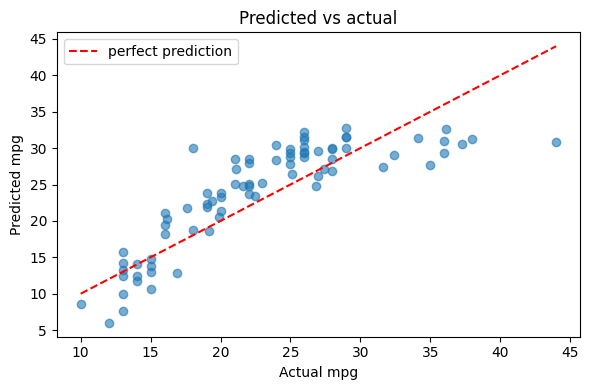

In [ ]:
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.6)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, "r--", label="perfect prediction")
plt.xlabel("Actual mpg"); plt.ylabel("Predicted mpg")
plt.title("Predicted vs actual"); plt.legend()
plt.tight_layout(); plt.show()

### Step 6.6: Which feature matters most?

Because every predictor was standardised to the same scale, the coefficient sizes are **directly comparable**.

In [ ]:
coefs = (pd.Series(model.coef_, index=features)
         .sort_values(key=abs, ascending=False))
print(coefs.round(2))

weight         -4.19
horsepower     -1.87
displacement   -0.70
cylinders      -0.30
acceleration   -0.17
dtype: float64


`weight` typically dominates with a strong negative sign — heavier cars burn more fuel — which matches the intuition PCA already hinted at. The fit is good but not perfect, leaving real residuals to discuss (model year and origin, which we left out, also carry signal).

**Rule of thumb**

Split before you scale. The scaler is part of the model and must never see the test data.

## Reflection Questions

Why must features be scaled before k-means, DBSCAN and PCA?

The k-means clusters scored near zero against `origin`. Was the clustering useless?

Why do we fit the scaler on the training set only, never the full dataset?

If RMSE is much larger than MAE, what does that tell you?

## Final Conceptual Exercise: Apply the workflow to the Diabetes dataset

Now apply the whole workflow to a fresh dataset. The **diabetes** dataset (built into scikit-learn) has 10 patient measurements and a continuous target: a quantitative measure of disease progression one year after baseline.

In [ ]:
from sklearn.datasets import load_diabetes

diab = load_diabetes(as_frame=True)
Xd = diab.data
yd = diab.target
print("Features:", list(Xd.columns))

Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


### Task 1: Understand the dataset

Is this a classification or a regression problem? How many features are there? Is the target categorical or continuous?

In [ ]:
print("Task 1: Dataset basics")

# TODO: Answer these by inspecting the data:
#   - Is this a classification or a regression problem? (look at the target yd)
#   - How many features does Xd have?
#   - Is the target continuous or categorical?
# Hints: Xd.shape, Xd.shape[1], yd.min(), yd.max()

# your code here


Task 1: Dataset basics


### Task 2: Scale, then reduce with PCA

Scale the features and report how much variance the first two principal components capture.

In [ ]:
print("Task 2: PCA")

# TODO: Scale the features, then reduce to 2 components with PCA.
#   1) X_scaled = StandardScaler().fit_transform(Xd)
#   2) Fit PCA(n_components=2) on the scaled data
#   3) Report the variance explained by PC1, PC2, and the two combined
# Hint: the fitted PCA has .explained_variance_ratio_

# your code here


Task 2: PCA


### Task 3: Cluster with k-means

Use the elbow method to pick *k*, then fit k-means on the scaled features.

In [ ]:
print("Task 3: K-means")

# TODO: Pick k with the elbow method, then cluster.
#   1) For k in range(1, 9): fit KMeans on the scaled features and record .inertia_
#      KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
#   2) Plot inertia against k and read off the elbow
#   3) Fit KMeans with your chosen k and print the cluster sizes
#      Hint: pd.Series(labels).value_counts()

# your code here


Task 3: K-means


### Task 4: Regression with the correct scaling discipline

Predict the target. Split first, fit the scaler on the training data only, then report MAE, RMSE and R².

In [ ]:
print("Task 4: Regression")

# TODO: Predict yd from Xd with the correct scaling discipline.
#   1) train_test_split(Xd.values, yd.values, test_size=0.2, random_state=RANDOM_STATE)
#   2) Fit StandardScaler on the TRAINING data ONLY, then transform train and test
#   3) Fit LinearRegression and predict on the test set
#   4) Print MAE, RMSE and R^2
# Remember: split BEFORE you scale, or the test set leaks into training.

# your code here


Task 4: Regression
